In [ ]:
import os
import torch
torch.set_default_dtype(torch.double)
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from nflows import flows, transforms, distributions

from src.diffeomorphisms.vector.starflow import StarFlowVectorDiffeomorphism
from src.dimension_reduction.principal_geodesic_analysis.vector.l2_tangent_space_pca import l2TangentSpacePCAVectorSolver
from src.distributions.star_gaussians.multi_inverse_pre_bias_linear_norm_gaussian import MultiInversePreBiasLinearStarNormGaussianDistribution
from src.distributions.star_gaussians.multi_inverse_pre_bias_diagonal_norm_gaussian import MultiInversePreBiasDiagonalStarNormGaussianDistribution
from src.embedding.hyperbolic_gromov_monge import HyperbolicGromovMongeEmbedding
from src.manifolds.euclidean.vector.pullback.standard import StandardPullbackVectorEuclidean
from src.manifolds.isometrized_euclidean.vector import l2IsometrizedVectorEuclidean
from src.training._gromov_monge_starflow import GromovMongeEmbeddingInformedStarFlowTraining
from src.transforms.vector.parity.simple_tanh import SimpleTanhParityVectorTransform
from src.transforms.vector.linear.lower_triangular import LowerTriangularLinearVectorTransform
from src.transforms.vector.linear.upper_triangular import UpperTriangularLinearVectorTransform

results_folder = os.path.join("results", "tree", "two_phase")
# fix seed
torch.manual_seed(31)

### Construct data set ###

Data shape: torch.Size([2000, 3])


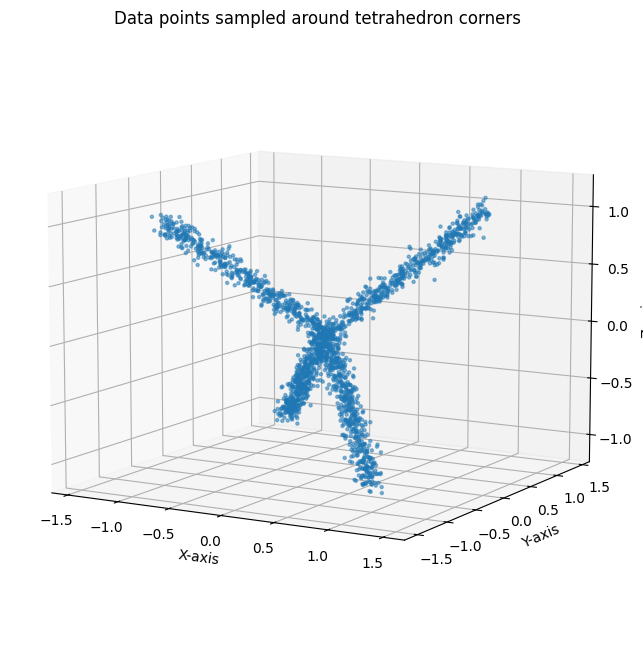

In [2]:
# construct data set from the four corners of a tetrahedron in R3
# construct tetrahedron corners
data_clusters = torch.tensor([[1.0, 1.0, 1.0],
                              [1.0, -1.0, -1.0],
                              [-1.0, 1.0, -1.0],
                              [-1.0, -1.0, 1.0]])

# generate data 
num_data_per_cluster = 500
sigma = 0.05
data = []
for center in data_clusters:
    for _ in range(num_data_per_cluster):
        t = torch.rand(1)
        point = t * center + (1 - t) * torch.zeros(3)
        point += sigma * torch.randn(3)  # small Gaussian noise
        data.append(point)
data = torch.stack(data)
print("Data shape:", data.shape)

# plot data in 3D
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(data[:, 0], data[:, 1], data[:, 2], s=5, alpha=0.5)
ax.set_title("Data points sampled around tetrahedron corners")
ax.set_xlabel("X-axis")
ax.set_ylabel("Y-axis")
ax.set_zlabel("Z-axis")
plt.axis('equal')
ax.view_init(elev=10)
plt.savefig(os.path.join(results_folder,"data.png"))
plt.show()

In [3]:
class RandomPairDataset(Dataset):
    def __init__(self, data):
        self.data = data            # shape: N x d
        self.N = data.shape[0]

    def __len__(self):
        return self.N  # you can pick another value if you wish

    def __getitem__(self, idx):
        # x: deterministic sample (makes training deterministic per epoch)
        x = self.data[idx]
        # x_prime: random sample, different from idx
        idx2 = torch.randint(0, self.N - 1, (1,)).item()
        if idx2 >= idx:
            idx2 += 1
        x_prime = self.data[idx2]
        return x, x_prime
    
# create dataset and dataloader
pair_dataset = RandomPairDataset(data)
dataloader = DataLoader(pair_dataset, batch_size=128, shuffle=True)

### Stage 1: Embed data set ###

In [4]:
# construct Gromov-Monge Embedding in Hyperbolic Space
# construct neural network architecture
class SimpleNN(torch.nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(SimpleNN, self).__init__()
        self.fc1 = torch.nn.Linear(input_dim, hidden_dim)
        self.fc2 = torch.nn.Linear(hidden_dim, hidden_dim)
        self.fc3 = torch.nn.Linear(hidden_dim, hidden_dim)
        self.fc4 = torch.nn.Linear(hidden_dim, output_dim)
        self.relu = torch.nn.ReLU()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.relu(self.fc3(x))
        x = self.fc4(x)
        return x
    
# instantiate the neural network
input_dim = 3
hidden_dim = 20
output_dim = 2  # we will embed into 2D hyperbolic space
nn_model = SimpleNN(input_dim, hidden_dim, output_dim)

# instantiate Gromov-Monge Embedding
T = HyperbolicGromovMongeEmbedding(nn_model, output_dim=2)

In [5]:
# construct train loop
optimizer = torch.optim.Adam(T.nn_model.parameters(), lr=0.001)
num_epochs = 50
for epoch in range(num_epochs):
    epoch_loss = 0.0
    for x, x_prime in dataloader:
        optimizer.zero_grad()
        dist_data = torch.norm(x - x_prime, dim=1)
        dist_emb = T.distance(x, x_prime)
        loss = torch.log((1 + dist_emb ** 2) / (1 + dist_data ** 2)).pow(2).mean()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * x.size(0)
    epoch_loss /= len(pair_dataset)
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss:.6f}")


Epoch 1/50, Loss: 1.169615
Epoch 2/50, Loss: 0.818463
Epoch 3/50, Loss: 0.362809
Epoch 4/50, Loss: 0.069795
Epoch 5/50, Loss: 0.033344
Epoch 6/50, Loss: 0.022632
Epoch 7/50, Loss: 0.020186
Epoch 8/50, Loss: 0.019139
Epoch 9/50, Loss: 0.018486
Epoch 10/50, Loss: 0.018421
Epoch 11/50, Loss: 0.017566
Epoch 12/50, Loss: 0.016720
Epoch 13/50, Loss: 0.016903
Epoch 14/50, Loss: 0.017359
Epoch 15/50, Loss: 0.017642
Epoch 16/50, Loss: 0.017426
Epoch 17/50, Loss: 0.017350
Epoch 18/50, Loss: 0.017079
Epoch 19/50, Loss: 0.018150
Epoch 20/50, Loss: 0.017342
Epoch 21/50, Loss: 0.016792
Epoch 22/50, Loss: 0.016509
Epoch 23/50, Loss: 0.016777
Epoch 24/50, Loss: 0.017277
Epoch 25/50, Loss: 0.017539
Epoch 26/50, Loss: 0.017403
Epoch 27/50, Loss: 0.017105
Epoch 28/50, Loss: 0.016618
Epoch 29/50, Loss: 0.016993
Epoch 30/50, Loss: 0.017496
Epoch 31/50, Loss: 0.017314
Epoch 32/50, Loss: 0.017673
Epoch 33/50, Loss: 0.016764
Epoch 34/50, Loss: 0.016971
Epoch 35/50, Loss: 0.016816
Epoch 36/50, Loss: 0.017552
E

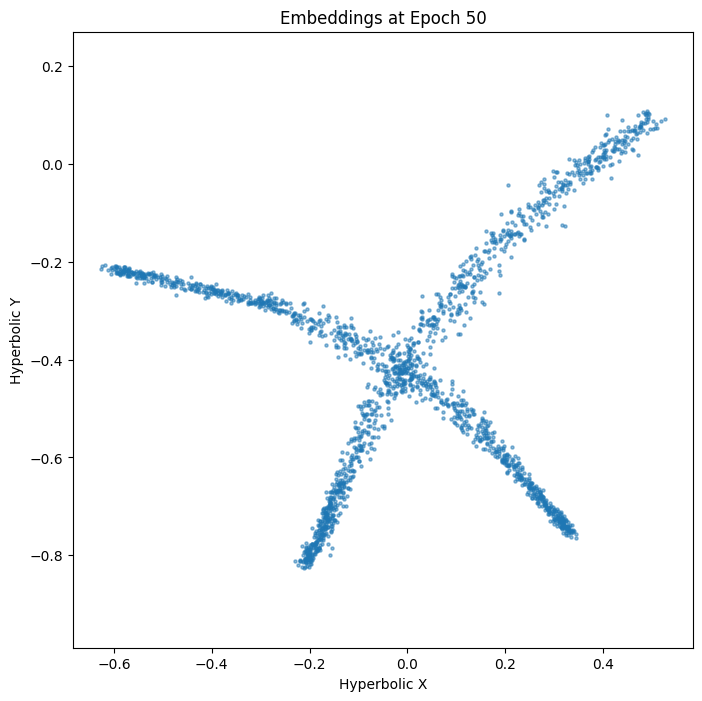

In [6]:
# visualize embeddings
with torch.no_grad():
    embeddings = T(data).cpu().numpy()
plt.figure(figsize=(8, 8))
plt.scatter(embeddings[:, 0], embeddings[:, 1], s=5, alpha=0.5)
plt.title(f"Embeddings at Epoch {epoch+1}")
plt.xlabel("Hyperbolic X")
plt.ylabel("Hyperbolic Y")
plt.axis('equal')
plt.savefig(os.path.join(results_folder,"emb_final.png"))
plt.show()

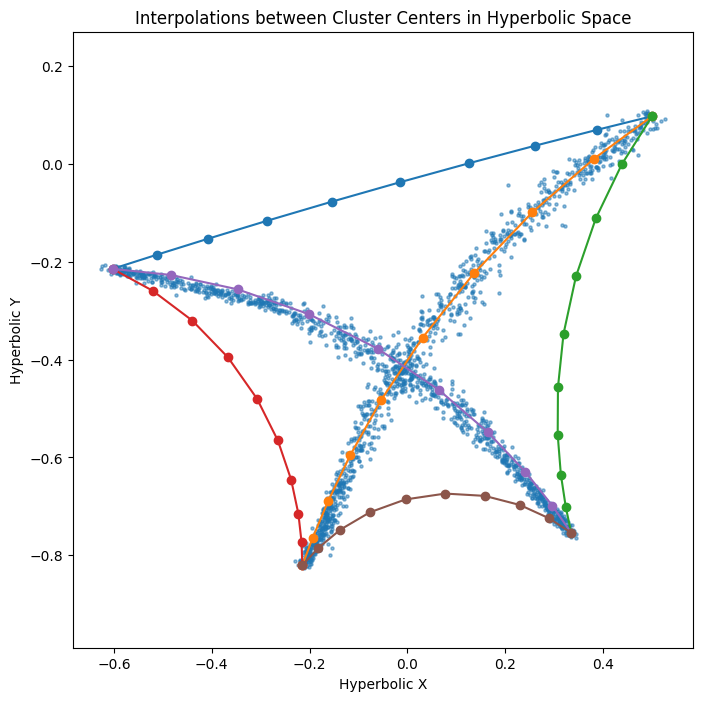

In [7]:
# interpolate between cluster centers
plt.figure(figsize=(8, 8))
plt.scatter(embeddings[:, 0], embeddings[:, 1], s=5, alpha=0.5)
for i in range(data_clusters.shape[0]):
    for j in range(i + 1, data_clusters.shape[0]):
        center1 = data_clusters[i].unsqueeze(0)
        center2 = data_clusters[j].unsqueeze(0)
        t_values = torch.linspace(0, 1, steps=10)
        with torch.no_grad():
            interp_points = T.interpolate(center1, center2, t_values)[0]
        # interp_points = interp_points.cpu().numpy()
        plt.plot(interp_points[:, 0], interp_points[:, 1], marker='o')
plt.title("Interpolations between Cluster Centers in Hyperbolic Space")
plt.xlabel("Hyperbolic X")
plt.ylabel("Hyperbolic Y")
plt.axis('equal')
plt.savefig(os.path.join(results_folder,"emb_final_geodesics.png"))
plt.show()

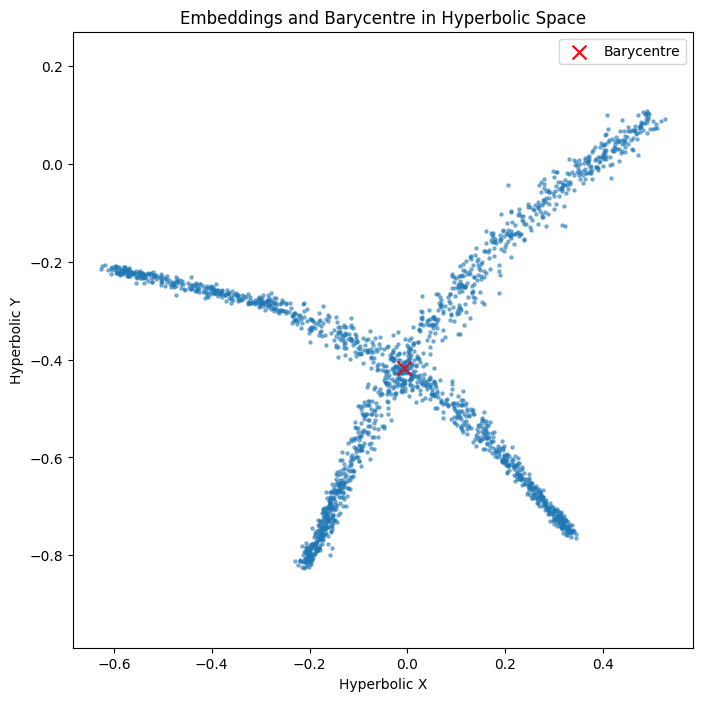

In [8]:
# we would like to compute the barycentre of the embeddings and use this to center the embeddings
with torch.no_grad():
    barycentre = T.barycentre(data)

plt.figure(figsize=(8, 8))
plt.scatter(embeddings[:, 0], embeddings[:, 1], s=5, alpha=0.5)
plt.scatter(barycentre[0].item(), barycentre[1].item(), color='red', marker='x', s=100, label='Barycentre')
plt.title("Embeddings and Barycentre in Hyperbolic Space")
plt.xlabel("Hyperbolic X")
plt.ylabel("Hyperbolic Y")
plt.axis('equal')
plt.legend()
plt.savefig(os.path.join(results_folder,"emb_final_bary.png"))
plt.show()  

In [9]:
# translate origin with isometr
# check that distances are preserved I: compute old distances
with torch.no_grad():
    dist_emb = T.distance(data_clusters[1:], data_clusters[:-1])

# update origin
T.set_origin(barycentre)

# check that distances are preserved II: compute new distances
with torch.no_grad():
    dist_emb_centered = T.distance(data_clusters[1:], data_clusters[:-1])

print("Pairwise distance matrix in embedding space between cluster centers:")
print((dist_emb - dist_emb_centered).abs().max())  # should be close to zero

Pairwise distance matrix in embedding space between cluster centers:
tensor(8.8818e-16)


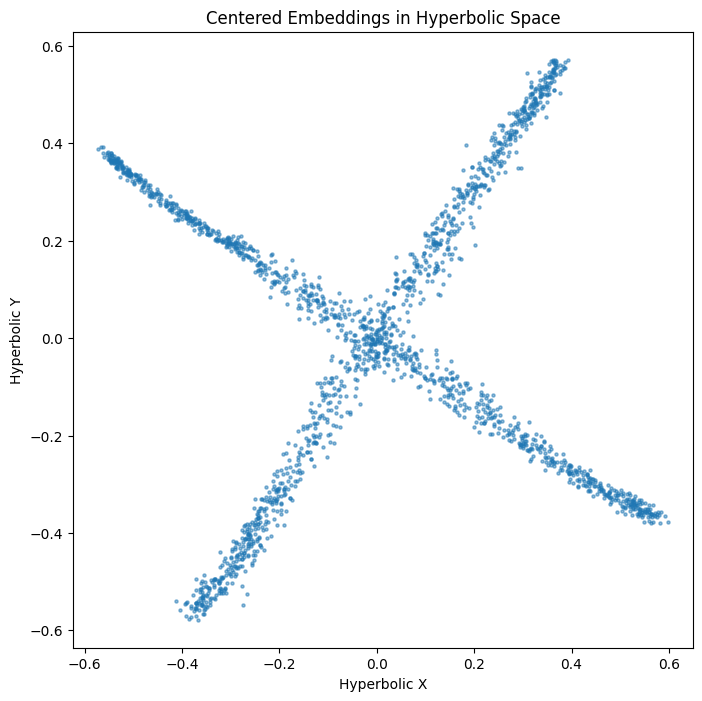

In [10]:
# compute embeddings again after centering
with torch.no_grad():
    embeddings_centered = T(data)
    
plt.figure(figsize=(8, 8))
plt.scatter(embeddings_centered[:, 0], embeddings_centered[:, 1], s=5, alpha=0.5)
plt.title("Centered Embeddings in Hyperbolic Space")
plt.xlabel("Hyperbolic X")
plt.ylabel("Hyperbolic Y")
plt.axis('equal')
plt.savefig(os.path.join(results_folder,"emb_final_centered.png"))
plt.show()

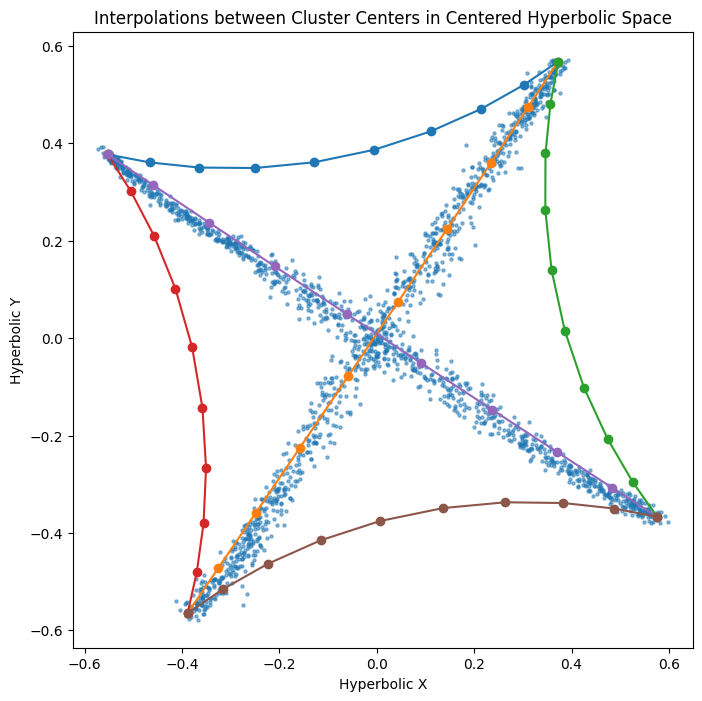

In [11]:
# interpolate between cluster centers after centering
plt.figure(figsize=(8, 8))
plt.scatter(embeddings_centered[:, 0], embeddings_centered[:, 1], s=5, alpha=0.5)
for i in range(data_clusters.shape[0]): 
    for j in range(i + 1, data_clusters.shape[0]):
        center1 = data_clusters[i].unsqueeze(0)
        center2 = data_clusters[j].unsqueeze(0)
        t_values = torch.linspace(0, 1, steps=10)
        with torch.no_grad():
            interp_points_centered = T.interpolate(center1, center2, t_values)[0]
        plt.plot(interp_points_centered[:, 0], interp_points_centered[:, 1], marker='o')
plt.title("Interpolations between Cluster Centers in Centered Hyperbolic Space")
plt.xlabel("Hyperbolic X")
plt.ylabel("Hyperbolic Y")
plt.axis('equal')
plt.savefig(os.path.join(results_folder,"emb_final_centered_geodesics.png"))
plt.show()

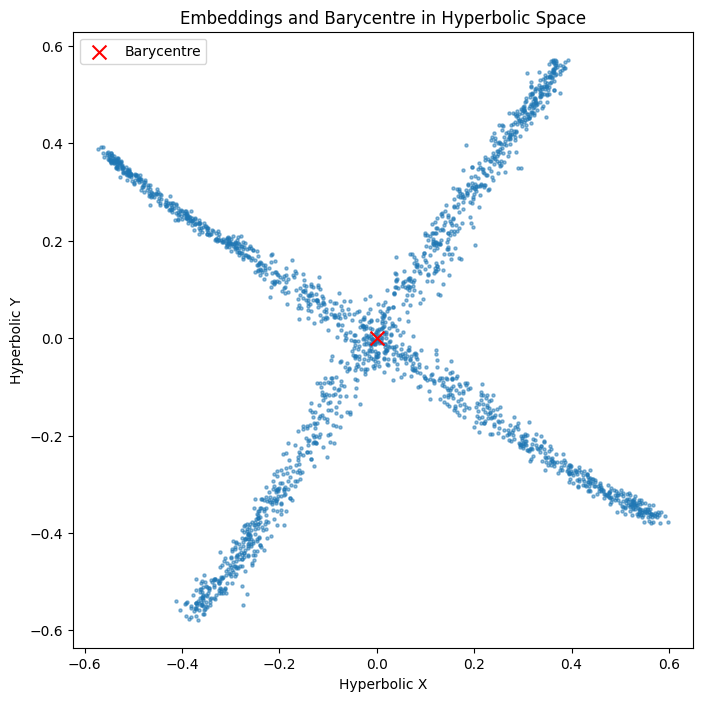

Distance between barycentres before and after centering:
1.6493864501619677e-05


In [12]:
# we would like to compute the barycentre of the embeddings and use this to center the embeddings
with torch.no_grad():
    barycentre_centered = T.barycentre(data)

plt.figure(figsize=(8, 8))
plt.scatter(embeddings_centered[:, 0], embeddings_centered[:, 1], s=5, alpha=0.5)
plt.scatter(barycentre_centered[0].item(), barycentre_centered[1].item(), color='red', marker='x', s=100, label='Barycentre')
plt.title("Embeddings and Barycentre in Hyperbolic Space")
plt.xlabel("Hyperbolic X")
plt.ylabel("Hyperbolic Y")
plt.axis('equal')
plt.legend()
plt.savefig(os.path.join(results_folder,"emb_final_centered_bary.png"))
plt.show()  

# check difference between barycentres
print("Distance between barycentres before and after centering:")
translated_barycentre = T.translate(barycentre, barycentre)
print((translated_barycentre - barycentre_centered).norm().item())  # should be close to zero

### Stage 2: Learn embedding-informed pullback geometry ###

In [13]:
# construct normalizing flow model
class SimpleStarFlowVectorDiffeomorphism(StarFlowVectorDiffeomorphism):
    def __init__(self, dim, hidden_dim, n_flows, n_modes):
        super(SimpleStarFlowVectorDiffeomorphism, self).__init__(dim, self.create_flow_model(dim, hidden_dim, n_flows, n_modes))

    def create_flow_model(self, dim, hidden_dim, n_flows, n_modes):
        base_dist = MultiInversePreBiasLinearStarNormGaussianDistribution(dim, n_modes)
        transforms_list = []
        for i in range(n_flows):
            transforms_list.append(UpperTriangularLinearVectorTransform(dim))
            transforms_list.append(LowerTriangularLinearVectorTransform(dim))
            transforms_list.append(SimpleTanhParityVectorTransform(dim, hidden_dim, parity=i))
        transforms_list.append(UpperTriangularLinearVectorTransform(dim))
        transforms_list.append(LowerTriangularLinearVectorTransform(dim))
        flow_transforms = transforms.CompositeTransform(transforms_list)
        return flows.Flow(transform=flow_transforms, distribution=base_dist)

# instantiate flow model
dim = 3
hidden_dim = 8
n_flows = 2
n_modes = 2
star_flow_diffeo = SimpleStarFlowVectorDiffeomorphism(dim, hidden_dim, n_flows, n_modes)
    
# instantiate GME-informed star flow
reg_param = 1e-4
gme_star_flow = GromovMongeEmbeddingInformedStarFlowTraining(T, star_flow_diffeo, reg_param=reg_param, sigma=sigma).double()
# freeze embedding model parameters
for param in gme_star_flow.emb.parameters():
    param.requires_grad = False

In [14]:
# construct train loop for the decoding diffeomorphism
optimizer_gme_star_flow_transform = torch.optim.Adam(list(gme_star_flow.star_flow_diffeo.transform.parameters()), lr=0.005, weight_decay=1e-5) 
num_epochs_flow = 500
for epoch in range(num_epochs_flow):
    epoch_loss = 0.0
    for x, _ in dataloader:
        optimizer_gme_star_flow_transform.zero_grad()
        loss = gme_star_flow.transform_loss(x)
        loss.backward()
        optimizer_gme_star_flow_transform.step()
        epoch_loss += loss.item() * x.size(0)
    epoch_loss /= len(pair_dataset)
    print(f"Flow Epoch {epoch+1}/{num_epochs_flow}, Loss: {epoch_loss:.6f}")

Flow Epoch 1/500, Loss: 0.559085
Flow Epoch 2/500, Loss: 0.323651
Flow Epoch 3/500, Loss: 0.217563
Flow Epoch 4/500, Loss: 0.179034
Flow Epoch 5/500, Loss: 0.160947
Flow Epoch 6/500, Loss: 0.146397
Flow Epoch 7/500, Loss: 0.132311
Flow Epoch 8/500, Loss: 0.118902
Flow Epoch 9/500, Loss: 0.107304
Flow Epoch 10/500, Loss: 0.097660
Flow Epoch 11/500, Loss: 0.088181
Flow Epoch 12/500, Loss: 0.077863
Flow Epoch 13/500, Loss: 0.065561
Flow Epoch 14/500, Loss: 0.052240
Flow Epoch 15/500, Loss: 0.042019
Flow Epoch 16/500, Loss: 0.036572
Flow Epoch 17/500, Loss: 0.034725
Flow Epoch 18/500, Loss: 0.033733
Flow Epoch 19/500, Loss: 0.033090
Flow Epoch 20/500, Loss: 0.032662
Flow Epoch 21/500, Loss: 0.031848
Flow Epoch 22/500, Loss: 0.031584
Flow Epoch 23/500, Loss: 0.030989
Flow Epoch 24/500, Loss: 0.030563
Flow Epoch 25/500, Loss: 0.030248
Flow Epoch 26/500, Loss: 0.029833
Flow Epoch 27/500, Loss: 0.029738
Flow Epoch 28/500, Loss: 0.029408
Flow Epoch 29/500, Loss: 0.029257
Flow Epoch 30/500, Loss

In [15]:
# construct training loop for the radial function
optimizer_gme_star_flow_radial = torch.optim.Adam(list(gme_star_flow.star_flow_diffeo.radial.parameters()), lr=0.005) 
num_epochs_flow = 500
for epoch in range(num_epochs_flow):
    epoch_loss = 0.0
    for x, _ in dataloader:
        optimizer_gme_star_flow_radial.zero_grad()
        loss = gme_star_flow.radial_loss(x)
        loss.backward()
        optimizer_gme_star_flow_radial.step()
        epoch_loss += loss.item() * x.size(0)
    epoch_loss /= len(pair_dataset)
    print(f"Flow Epoch {epoch+1}/{num_epochs_flow}, Loss: {epoch_loss:.6f}")

Flow Epoch 1/500, Loss: 6.556488
Flow Epoch 2/500, Loss: 5.944090
Flow Epoch 3/500, Loss: 5.479076
Flow Epoch 4/500, Loss: 5.097848
Flow Epoch 5/500, Loss: 4.787351
Flow Epoch 6/500, Loss: 4.517253
Flow Epoch 7/500, Loss: 4.284785
Flow Epoch 8/500, Loss: 4.075163
Flow Epoch 9/500, Loss: 3.889790
Flow Epoch 10/500, Loss: 3.719171
Flow Epoch 11/500, Loss: 3.561885
Flow Epoch 12/500, Loss: 3.421404
Flow Epoch 13/500, Loss: 3.288535
Flow Epoch 14/500, Loss: 3.168216
Flow Epoch 15/500, Loss: 3.052522
Flow Epoch 16/500, Loss: 2.946256
Flow Epoch 17/500, Loss: 2.846514
Flow Epoch 18/500, Loss: 2.751482
Flow Epoch 19/500, Loss: 2.663531
Flow Epoch 20/500, Loss: 2.581038
Flow Epoch 21/500, Loss: 2.502035
Flow Epoch 22/500, Loss: 2.427392
Flow Epoch 23/500, Loss: 2.354608
Flow Epoch 24/500, Loss: 2.287291
Flow Epoch 25/500, Loss: 2.224802
Flow Epoch 26/500, Loss: 2.162293
Flow Epoch 27/500, Loss: 2.102532
Flow Epoch 28/500, Loss: 2.045044
Flow Epoch 29/500, Loss: 1.993275
Flow Epoch 30/500, Loss

In [16]:
# construct manifold from learned flow
manifold = StandardPullbackVectorEuclidean(gme_star_flow.star_flow_diffeo)
# construct iso_manifold 
iso_manifold = l2IsometrizedVectorEuclidean(manifold)

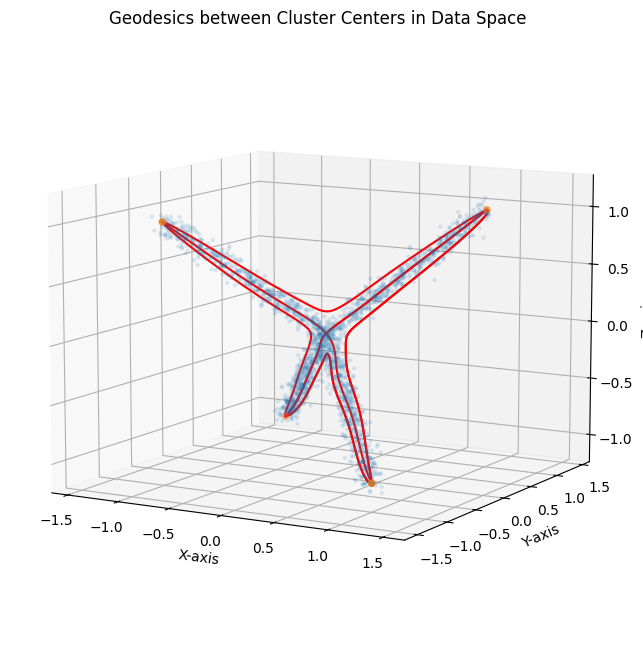

In [17]:
# compute geodesics between all pairs of points
t = torch.linspace(0, 1, steps=100)
with torch.no_grad():
    geodesics = iso_manifold.geodesic(data_clusters[None], data_clusters[None], t)

# plot geodesics
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')
# plot data points
ax.scatter(data[:, 0].numpy(), data[:, 1].numpy(), data[:, 2].numpy(), s=5, alpha=0.1, label='Original Data')
for i in range(geodesics.shape[1]):
    for j in range(geodesics.shape[2]-1):
        ax.plot(geodesics[0, i, j, :, 0].numpy(), geodesics[0, i, j, :, 1].numpy(), geodesics[0, i, j, :, 2].numpy(), 'r-')
ax.scatter(data_clusters[:, 0].numpy(), data_clusters[:, 1].numpy(), data_clusters[:, 2].numpy())
ax.set_title("Geodesics between Cluster Centers in Data Space")
ax.set_xlabel("X-axis")
ax.set_ylabel("Y-axis")
ax.set_zlabel("Z-axis")
plt.axis('equal')
ax.view_init(elev=10)
plt.savefig(os.path.join(results_folder,"data_geodesics.png"))
plt.show()

In [18]:
# # sanity check: is the embedding still the same (and was not accidentally changed during flow training)
# with torch.no_grad():
#     embeddings_after_flow = gme_star_flow.emb(data)
# print("Max difference in embeddings before and after flow training:", (embeddings_after_flow - embeddings_centered).abs().max().item())  # should be close to zero

iteration 1 | error = 0.0023239443588733187
iteration 2 | error = 0.0012279875965158686
iteration 3 | error = 0.0006634376185193877
iteration 4 | error = 0.0003604386045625507
iteration 5 | error = 0.00019554207918181775
iteration 6 | error = 0.0001057531776376284
iteration 7 | error = 5.70328364396511e-05
gradient descent was terminated after reaching a error 5.70328364396511e-05 in 7 iterations
Computing rank 2 approximation on tangent space
Computing rank 2 approximation on euclidean space
Computing rank 2 errors


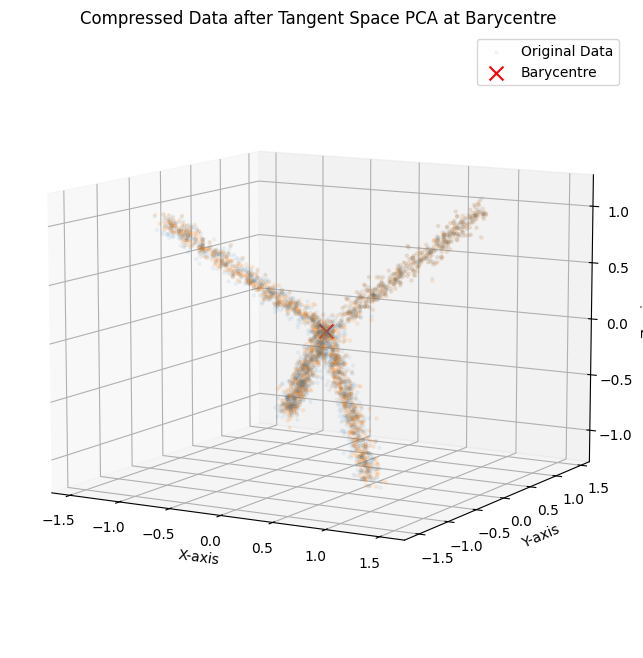

Mean reconstruction error after compression: 0.05183779901845684


In [19]:
# compute data barycentre
barycentre_data = iso_manifold.barycentre(data, tol=1e-4, max_iter=100, step_size=0.5)
# tangent space PCA to find principal directions at data barycentre
l2_pga_solver_bary = l2TangentSpacePCAVectorSolver(data, iso_manifold, barycentre_data)
# compute principal directions
_, compressed_data, _ = l2_pga_solver_bary.solve(2)

# plot compressed data in 3D
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')
# plot original data
ax.scatter(data[:, 0].numpy(), data[:, 1].numpy(), data[:, 2].numpy(), s=5, alpha=0.05, label='Original Data')
# plot compressed data
ax.scatter(compressed_data[:, 0].numpy(), compressed_data[:, 1].numpy(), compressed_data[:, 2].numpy(), s=5, alpha=0.1)
# plot barycentre
ax.scatter(barycentre_data[0].item(), barycentre_data[1].item(), barycentre_data[2].item(), color='red', marker='x', s=100, label='Barycentre')
plt.title("Compressed Data after Tangent Space PCA at Barycentre")
ax.set_xlabel("X-axis")
ax.set_ylabel("Y-axis")
ax.set_zlabel("Z-axis")
plt.axis('equal')
plt.legend()
ax.view_init(elev=10)
plt.savefig(os.path.join(results_folder,"data_compressed.png"))
plt.show()

# compute error between original data and compressed data
rel_error = (torch.norm(data - compressed_data, dim=1).mean() / torch.norm(data, dim=1).mean()).item()
print("Mean reconstruction error after compression:", rel_error)

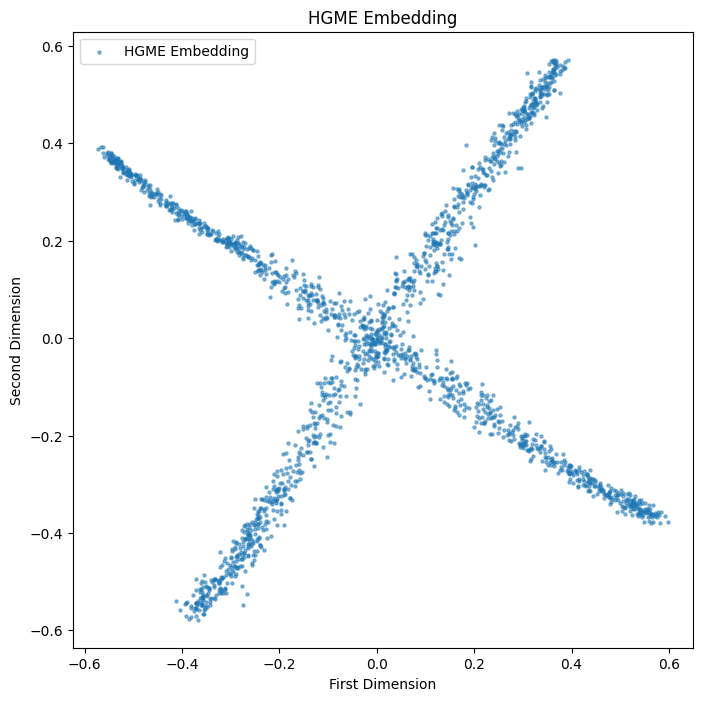

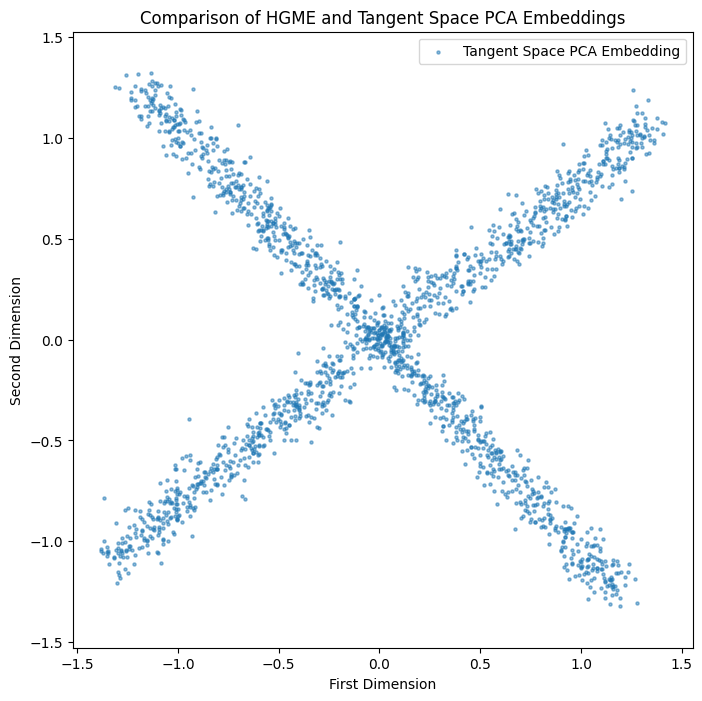

In [20]:
# compare embeddings
pca_embedding = l2_pga_solver_bary.get_embedding(2)

# plot embeddings comparison in different figures (because different spaces)
plt.figure(figsize=(8, 8))
plt.scatter(embeddings_centered[:, 0], embeddings_centered[:, 1], s=5, alpha=0.5, label='HGME Embedding')
plt.title("HGME Embedding")
plt.xlabel("First Dimension")
plt.ylabel("Second Dimension")
plt.legend()    
plt.axis('equal')
plt.show()

plt.figure(figsize=(8, 8))
plt.scatter(pca_embedding[:, 0], pca_embedding[:, 1], s=5, alpha=0.5, label='Tangent Space PCA Embedding')
plt.title("Comparison of HGME and Tangent Space PCA Embeddings")
plt.xlabel("First Dimension")
plt.ylabel("Second Dimension")
plt.legend()    
plt.axis('equal')
plt.savefig(os.path.join(results_folder,"emb_comparison.png"))
plt.show()